In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# In vivo inputs

In [2]:
def read_all_weights(dir = "../output/temporal-interference-1", stimulation = "1000_5_0.5_0.1"):
  print(f"Processing stimulation {stimulation}")
  cell_ids = np.arange(0, 20)
  cell_weights = {}
  time = []
  for cell_id in cell_ids:
    cell_weights[cell_id] = pd.read_csv(f"{dir}/{cell_id}/in-vivo/{stimulation}/synapse_weights.csv", index_col = 0)
    time.append(cell_weights[cell_id].Time)

  time = np.concatenate(time)
  time = np.unique(time)
  time = np.sort(time)
  print(f"Number of time points: {len(time)}")

  synapses = [ f"Synapse{id}" for id in range(0, 10) ]
  for cell_id in cell_ids:
    cell_weights[cell_id] = (
      cell_weights[cell_id].set_index("Time")[synapses]
      .reindex(time, method = "ffill")
      .to_numpy()
      .T
    )

  weights = np.concatenate([
    cell_weights[cell_id]
    for cell_id in cell_ids
  ], axis = 0)

  weights = pd.DataFrame(
    weights.T,
    index = time
  )

  return weights

In [3]:
colors = {
  "No tTIS": "#0D0887",
  "50% tTIS": "#E16462",
  "90% tTIS": "#B12A90"
}

stimulations = list(colors.keys())

weights = {
  "No tTIS": read_all_weights("../output/temporal-interference-1", "noTI_0.1"),
  "50% tTIS": read_all_weights("../output/temporal-interference-1", "1000_5_0.5_0.1"),
  "90% tTIS": read_all_weights("../output/temporal-interference-1", "1000_5_0.9_0.1")
}

Processing stimulation noTI_0.1
Number of time points: 6778
Processing stimulation 1000_5_0.5_0.1
Number of time points: 8677
Processing stimulation 1000_5_0.9_0.1
Number of time points: 12166


## Average weight change (overall)

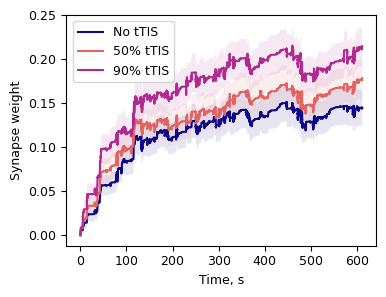

In [4]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 3))

ax = axs
for stimulation in stimulations:
  w = np.abs(weights[stimulation] - 0.1)
  time = w.index / 1000
  mean = w.mean(axis = 1)
  error = w.std(axis = 1) / np.sqrt(w.shape[1])

  ax.plot(time, mean, label = stimulation, color = colors[stimulation])

  ax.fill_between(
    time,
    mean - error,
    mean + error,
    alpha = 0.1,
    color = colors[stimulation],
    edgecolor = None
  )

ax.set_xlabel("Time, s")
ax.set_ylabel("Synapse weight")
ax.legend()

plt.show()

## Fraction of potentiated and depressed synapses

In [5]:
def categorize(w, atol = 1e-4):
  if w > 0.1 + atol: return "LTP"
  if w < 0.1 - atol: return "LTD"
  return "no change"

def get_category_counts(weights, atol = 1e-4):
  order = [
    "LTD",
    "no change",
    "LTP"
  ]
  
  final_weight_categories = []
  for stimulation in weights.keys():
    max_time = weights[stimulation].index.max()
    time_select = max_time - 0.5 * 1000

    time_index = np.where(weights[stimulation].index > time_select)[0]

    w = weights[stimulation].iloc[time_index, :].mean(axis = 0)
    
    final = pd.DataFrame({
      "Amplitude": stimulation,
      "Weight": w,
      "Category": [ categorize(_w, atol) for _w in w ]
    })

    final["Category"] = pd.Categorical(final["Category"], categories = order, ordered = True)
    final_weight_categories.append(final)

  final_weight_categories = pd.concat(final_weight_categories)

  group_counts = (
    final_weight_categories
    .groupby(["Amplitude", "Category"], observed = True)
    .size()
    .reset_index(name = "Count")
  )

  group_props = (
    group_counts
    .groupby("Amplitude", group_keys=False)
    .apply(lambda df: df.assign(Proportion = df["Count"] / df["Count"].sum()))
  )

  pivot = group_props.pivot(index = "Amplitude", columns = "Category", values = "Proportion")
  new_order = [ x for x in order if x in group_props["Category"].unique() ]
  pivot = pivot[new_order].fillna(0)

  priority = ["No tTIS", "50% tTIS", "90% tTIS"]
  new_index = priority + [i for i in pivot.index if i not in priority]
  pivot = pivot.loc[new_index]

  return pivot

palette = {
  "LTD": "#0D0887",
  "no change": "#CCCCCC",
  "LTP": "#E16462"
}

In [6]:
def plot_bardistributions(weights, ax):
  pivot = get_category_counts(weights)

  y_pos = range(len(pivot.index))
  left = [0] * len(pivot.index)

  for group in pivot.columns.values:
    values = pivot[group].values
    bars = ax.barh(
      y_pos,
      values,
      left=left,
      color=palette[group],
      edgecolor="white",
      linewidth=1,
      height=0.9,
      label=group,
      alpha = 0.9
    )
    left = [l + v for l, v in zip(left, values)]

    # annotate percentages

    for bar, v in zip(bars, values):
      if v == 0: continue
      text_col = "white" if group == "LTD" else "black"
      
      ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{v * 200:.0f}",
        ha = "center",
        va = "center",
        fontsize = 8,
        c = text_col
      )

  ax.set_yticks(y_pos)
  ax.set_yticklabels(pivot.index)

  ax.set_xlabel("")
  ax.tick_params(bottom = False, labelbottom = False)
  ax.set_xlim(0, 1)

  ax.invert_yaxis()

  ax.spines["top"].set_visible(False)
  ax.spines["bottom"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["left"].set_visible(False)

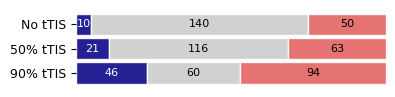

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 1))
plot_bardistributions(weights, axs)

## Weight heatmap

In [8]:
def plot_weight_heatmap(ax, data, show_cbar = False, show_ylabel = True):
  synapse_order = np.argsort(data.iloc[-1].values)[::-1]
  heatmap_df = data.iloc[:, synapse_order].T.copy()

  cmap = LinearSegmentedColormap.from_list(
    "custom_weights",
    [
      (0.0, "#0D0887"),
      (0.1, "#CCCCCC"),
      (0.2, "#FCA636"),
      (0.7, "#E16462"),
      (1.0, "#B12A90")
    ]
  )

  im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=1
  )

  # x ticks
  time_values = heatmap_df.columns.values / 1000
  tick_times = np.arange(0, time_values[-1] + 100, 200).astype(int)

  tick_positions = np.searchsorted(time_values, tick_times)
  ax.set_xticks(tick_positions)
  ax.set_xticklabels(tick_times)

  ax.set_yticks([])
  if show_ylabel:
    ax.set_ylabel("Synapse")

  ax.set_xlabel("Time (s)")

  if show_cbar:
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Weight")

  return im

In [9]:
def expand_time(weights, time_step = 0.025, sample_time_step = 0.5):
  print(f"Original data dimensions: {weights.shape}")
  time = weights.index
  weights_to_update = weights.copy()
  max_time = time.max()

  time = (time / time_step).round() * time_step
  weights_to_update.index = time

  new_time = np.arange(0, max_time + time_step, time_step)
  new_weights = pd.DataFrame(weights_to_update).set_index(time).reindex(new_time, method = "ffill")
  print(f"Expanded data dimensions: {new_weights.shape}")

  # sample every sample_time_step
  sampled_time = np.arange(0, max_time, sample_time_step)
  new_weights = new_weights.loc[sampled_time]
  print(f"Resampled data dimensions: {new_weights.shape}")

  return new_weights

expanded_weights = {
  "No tTIS": expand_time(weights = weights["No tTIS"]),
  "50% tTIS": expand_time(weights = weights["50% tTIS"]),
  "90% tTIS": expand_time(weights = weights["90% tTIS"])
}

Original data dimensions: (6778, 200)
Expanded data dimensions: (24445131, 200)
Resampled data dimensions: (1222257, 200)
Original data dimensions: (8677, 200)
Expanded data dimensions: (24445133, 200)
Resampled data dimensions: (1222257, 200)
Original data dimensions: (12166, 200)
Expanded data dimensions: (24445126, 200)
Resampled data dimensions: (1222257, 200)


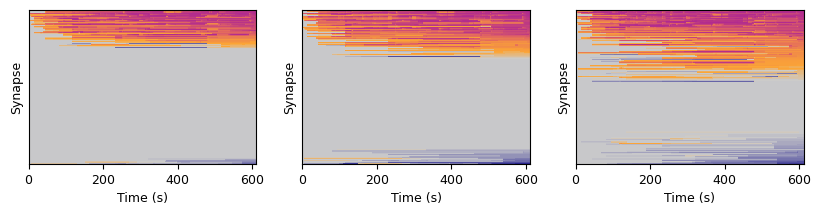

In [10]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (10, 2))

plot_weight_heatmap(
  axs[0],
  expanded_weights["No tTIS"]
)

plot_weight_heatmap(
  axs[1],
  expanded_weights["50% tTIS"]
)

plot_weight_heatmap(
  axs[2],
  expanded_weights["90% tTIS"]
)

plt.show()

## LTP / LTD dynamics

No tTIS
ltp
0.5770640614396845
50% tTIS
ltp
0.5242061070294947
90% tTIS
ltp
0.45013768888394595
No tTIS
ltd
0.09671116833973167
50% tTIS
ltd
0.09028570941966771
90% tTIS
ltd
0.09360235112717345


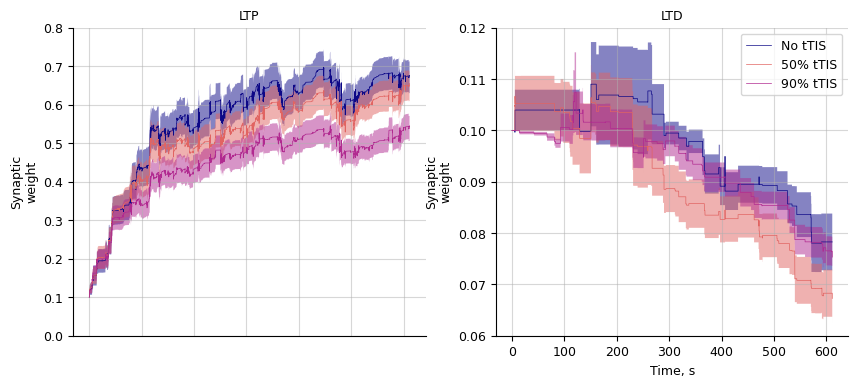

In [11]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

for ax, type in zip(axs, ["ltp", "ltd"]):
  for stimulation in weights.keys():
    max_time = weights[stimulation].index.max()
    time_select = max_time - 0.5 * 1000

    time_index = np.where(weights[stimulation].index > time_select)[0]

    final = weights[stimulation].iloc[time_index, :].mean(axis = 0)
    color = colors[stimulation]

    selected_ids = np.where(final > 0.1 + 0.0001)[0] if type == "ltp" else np.where(final < 0.1 - 0.0001)[0]
    
    w = weights[stimulation].iloc[:, selected_ids]

    dynamics = pd.DataFrame({
      "Time": w.index / 1000,
      "Mean": w.mean(axis = 1),
      "Error": w.std(axis = 1) / np.sqrt(w.shape[1])
    })

    # smoothed_change = moving_average(dynamics.Mean.values, window)
    # smoothed_error = moving_average(dynamics.Error.values, window)

    ax.plot(
      dynamics.Time,
      dynamics.Mean,
      linewidth = 0.5,
      label = stimulation,
      color = color
    )

    ax.fill_between(
      dynamics.Time,
      dynamics.Mean - dynamics.Error,
      dynamics.Mean + dynamics.Error,
      alpha = 0.5,
      color = color,
      edgecolor = None
    )

    print(stimulation)
    print(type)
    print(dynamics.Mean.mean())

  ax.set_xlabel("Time, s")
  ax.set_ylabel("Synaptic\nweight")

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  if type == "ltp":
    # ax.set_yticks(np.arange(0, 0.51, 0.2))
    ax.set_ylim(0, 0.8)
  
  if type == "ltd":
    # ax.set_yticks(np.arange(0, 0.51, 0.2))
    ax.set_ylim(0.06, 0.12)

  ax.grid(alpha = 0.5)
  ax.autoscale(False)

  if type == "ltp":
    ax.tick_params(bottom = False, labelbottom = False, top = False, labeltop = False)
    ax.set_xlabel("")

  
# axs[0].set_ylim(0.1, 0.45)
# axs[1].set_ylim(0.08, 0.11)

axs[0].set_title("LTP")
axs[1].set_title("LTD")

axs[1].legend()

## Final weight histograms

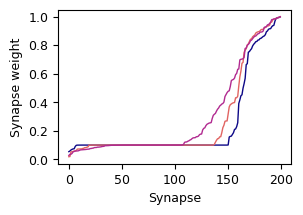

In [12]:
plt.figure(figsize = (3, 2))

for stimulation in stimulations:
  max_time = weights[stimulation].index.max()
  time_select = max_time - 0.5 * 1000
  time_index = np.where(weights[stimulation].index > time_select)[0]
  final = weights[stimulation].iloc[time_index, :].mean(axis = 0)

  plt.plot(
    np.sort(final),
    label = stimulation,
    color = colors[stimulation],
    linewidth = 1
  )

plt.xlabel("Synapse")
plt.ylabel("Synapse weight")
plt.show()

## Somatic firing frequency

In [13]:
cell_ids = np.arange(0, 20)
rates = {
  "No tTIS": [],
  "50% tTIS": [],
  "90% tTIS": []
}

for cell_id in cell_ids:
  spikes = pd.read_csv(f"../output/temporal-interference-1/{cell_id}/in-vivo/1000_5_0.5_0.1/spike_frequency.csv", index_col = 0)
  rate = (len(spikes) + 1 if len(spikes) >= 1 else 0) / (610)
  rates["50% tTIS"].append(rate)

  spikes = pd.read_csv(f"../output/temporal-interference-1/{cell_id}/in-vivo/1000_5_0.9_0.1/spike_frequency.csv", index_col = 0)
  rate = (len(spikes) + 1 if len(spikes) >= 1 else 0) / (610)
  rates["90% tTIS"].append(rate)

  spikes = pd.read_csv(f"../output/temporal-interference-1/{cell_id}/in-vivo/noTI_0.1/spike_frequency.csv", index_col = 0)
  rate = (len(spikes) + 1 if len(spikes) >= 1 else 0) / (610)
  rates["No tTIS"].append(rate)

In [14]:
rates = pd.DataFrame(rates)

mean = rates["No tTIS"].mean()
sd = rates["No tTIS"].std()
print(f"No tTIS: {mean:.2f} +- {sd:.2f}")

mean = rates["50% tTIS"].mean()
sd = rates["50% tTIS"].std()
print(f"50% tTIS: {mean:.2f} +- {sd:.2f}")

mean = rates["90% tTIS"].mean()
sd = rates["90% tTIS"].std()
print(f"90% tTIS: {mean:.2f} +- {sd:.2f}")

No tTIS: 0.00 +- 0.00
50% tTIS: 0.05 +- 0.07
90% tTIS: 0.27 +- 0.25


/home/ikerseviciute/miniconda3/envs/neuron/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


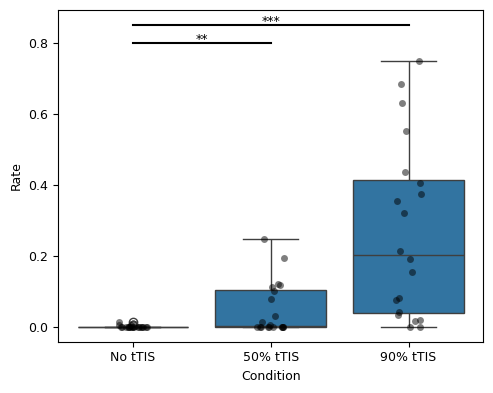

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

df = rates
df_long = df.melt(var_name="Condition", value_name="Rate")

_, p_50 = wilcoxon(df["No tTIS"], df["50% tTIS"], alternative="two-sided")
_, p_90 = wilcoxon(df["No tTIS"], df["90% tTIS"], alternative="two-sided")

def p_to_stars(p):
    if p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

plt.figure(figsize=(5,4))
ax = sns.boxplot(data=df_long, x="Condition", y="Rate")
sns.stripplot(data=df_long, x="Condition", y="Rate", color="black", alpha=0.5)

y_max = df.values.max()
offset = 0.05

ax.plot([0,1],[y_max+offset,y_max+offset], color="black")
ax.text(0.5, y_max+offset, p_to_stars(p_50), ha="center")

ax.plot([0,2],[y_max+2*offset,y_max+2*offset], color="black")
ax.text(1, y_max+2*offset, p_to_stars(p_90), ha="center")

plt.tight_layout()
plt.show()

## Voltage traces

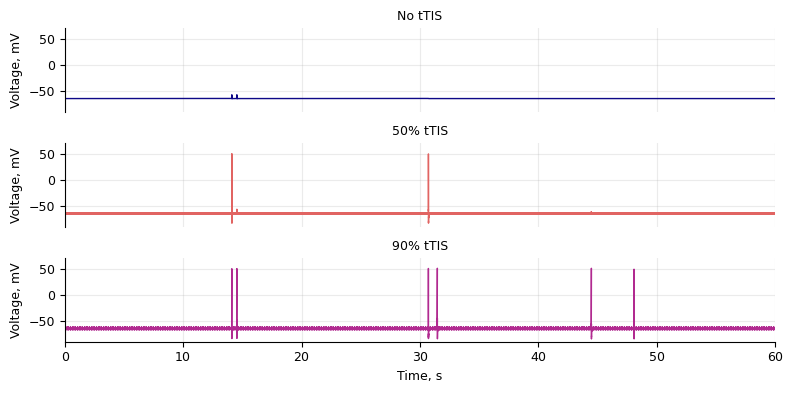

In [16]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (8, 4), sharey = True, sharex = True)

linewidth = 1
cell_id = 2

voltage_no_ti = pd.read_csv(f"../output/temporal-interference-1/{cell_id}/in-vivo/noTI_0.1/voltage.csv", index_col = 0)
axs[0].plot(voltage_no_ti.Time / 1000, voltage_no_ti.Voltage, linewidth = linewidth, color = colors["No tTIS"])
axs[0].set_title("No tTIS")

voltage_ti_50 = pd.read_csv(f"../output/temporal-interference-1/{cell_id}/in-vivo/1000_5_0.5_0.1/voltage.csv", index_col = 0)
axs[1].plot(voltage_ti_50.Time / 1000, voltage_ti_50.Voltage, linewidth = linewidth, color = colors["50% tTIS"])
axs[1].set_title("50% tTIS")

voltage_ti_90 = pd.read_csv(f"../output/temporal-interference-1/{cell_id}/in-vivo/1000_5_0.9_0.1/voltage.csv", index_col = 0)
axs[2].plot(voltage_ti_90.Time / 1000, voltage_ti_90.Voltage, linewidth = linewidth, color = colors["90% tTIS"])
axs[2].set_title("90% tTIS")

axs[2].set_xlabel("Time, s")

for ax in axs:
  ax.set_ylabel("Voltage, mV")
  ax.grid(alpha = 0.25)
  ax.set_xlim(0, 60)
  ax.set_ylim(-90, 70)
  ax.set_yticks([-50, 0, 50])

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

for ax in axs[0:2]:
  ax.spines["bottom"].set_visible(False)
  ax.tick_params(bottom = False)

plt.tight_layout()
plt.show()

## LTP / LTD dynamics within the same synapse

In [17]:
from itertools import product

final_weights = {}

for stimulation in ["50% tTIS", "90% tTIS"]:
  final_weights[stimulation] = {}
  for type in ["ltp", "ltd"]:
    max_time = weights[stimulation].index.max()
    time_select = max_time - 0.5 * 1000

    time_index = np.where(weights[stimulation].index > time_select)[0]

    final = weights[stimulation].iloc[time_index, :].mean(axis = 0)
    color = colors[stimulation]

    selected_ids_ti = np.where(final > 0.1 + 0.0001)[0] if type == "ltp" else np.where(final < 0.1 - 0.0001)[0]

    ## Calculate the same for no ti
    max_time = weights["No tTIS"].index.max()
    time_select = max_time - 0.5 * 1000

    time_index = np.where(weights["No tTIS"].index > time_select)[0]
    final_no_TI = weights["No tTIS"].iloc[time_index, ].mean(axis = 0)

    selected_ids_no_ti = np.where(final_no_TI > 0.1 + 0.0001)[0] if type == "ltp" else np.where(final_no_TI < 0.1 - 0.0001)[0]

    selected = np.concatenate([selected_ids_ti, selected_ids_no_ti])
    selected = np.unique(selected)
    selected = np.sort(selected)

    final = final[selected]
    final_no_TI = final_no_TI[selected]

    final_weights[stimulation][type] = {
      "TI": final.values,
      "No TI": final_no_TI.values
    }

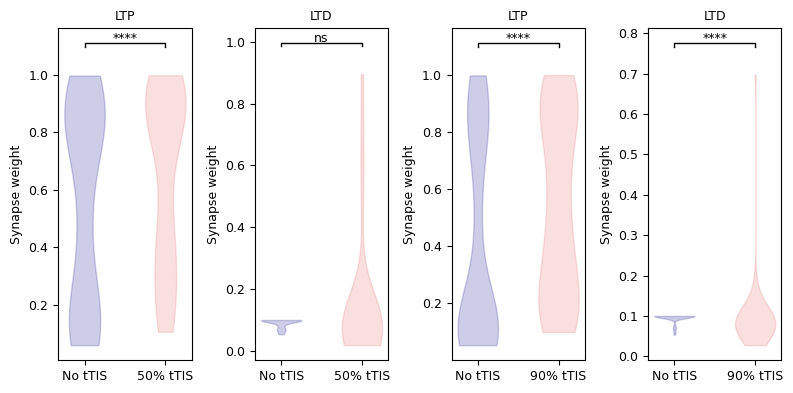

In [18]:
import numpy as np
import matplotlib.pyplot as plt

type = "ltd"
stimulation = "50% tTIS"

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (8, 4))
axs_i = 0

for stimulation in final_weights.keys():
  for type in ["ltp", "ltd"]:
    ax = axs[axs_i]
    axs_i = axs_i + 1

    data = final_weights[stimulation][type]
    y1 = data["No TI"]
    y2 = data["TI"]

    x = [0, 1]
    jitter = 0.05
    x1 = np.random.normal(loc=0, scale=jitter, size=len(y1))
    x2 = x1 + 1

    # for i in range(len(y1)):
    #   if y1[i] > y2[i]:
    #     color = colors["No tTIS"]
    #   else:
    #     color = colors["50% tTIS"]

    #   points_x = [ x1[i], x2[i] ]
    #   points_y = [ y1[i], y2[i] ]

    #   ax.plot(points_x, points_y, color = color, linewidth = 0.25, alpha = 1)
    #   ax.scatter(points_x, points_y, color=color, s=30, alpha = 0.25)

    # violin plots
    parts = ax.violinplot(
        [y1, y2],
        positions=x,
        widths=0.5,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    # style
    for pc, c in zip(parts["bodies"], [colors["No tTIS"], colors["50% tTIS"]]):
        pc.set_facecolor(c)
        pc.set_alpha(0.2)
        pc.set_edgecolor(c)
        pc.set_linewidth(1)

    stat, p = wilcoxon(y1, y2)

    stars = p_to_stars(p)

    # position for annotation
    y_max = max(np.max(y1), np.max(y2))
    # if (type == "ltd"):
    #   y_max = 0.1
    
    y = y_max * 1.1

    ax.plot([0, 0, 1, 1], [y, y * 1.01, y * 1.01, y], color="black", linewidth=1)
    ax.text(0.5, y+0.005, stars, ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x, ["No tTIS", stimulation])
    ax.set_ylabel("Value")
    # ax.set_xlim(-0.2, 1.2)

    # if type == "ltd":
    #   ax.set_ylim(0, 0.12)
    ax.set_ylabel("Synapse weight")

    if type == "ltp":
      ax.set_title("LTP")
    if type == "ltd":
      ax.set_title("LTD")

plt.tight_layout()
plt.show()

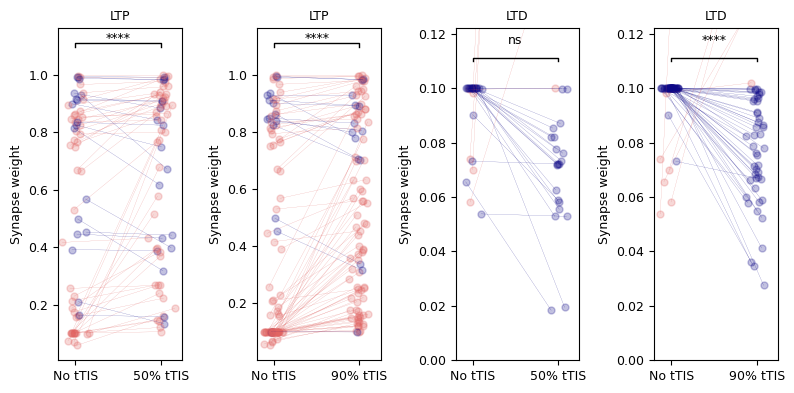

In [19]:
import numpy as np
import matplotlib.pyplot as plt

type = "ltd"
stimulation = "50% tTIS"

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (8, 4))
axs_i = 0

for type in ["ltp", "ltd"]:
  for stimulation in final_weights.keys():
    ax = axs[axs_i]
    axs_i = axs_i + 1

    data = final_weights[stimulation][type]
    y1 = data["No TI"]
    y2 = data["TI"]

    x = [0, 1]
    jitter = 0.05
    x1 = np.random.normal(loc=0, scale=jitter, size=len(y1))
    x2 = x1 + 1

    for i in range(len(y1)):
      if y1[i] > y2[i]:
        color = colors["No tTIS"]
      else:
        color = colors["50% tTIS"]

      points_x = [ x1[i], x2[i] ]
      points_y = [ y1[i], y2[i] ]

      ax.plot(points_x, points_y, color = color, linewidth = 0.1, alpha = 1)
      ax.scatter(points_x, points_y, color=color, s=25, alpha = 0.25)

    stat, p = wilcoxon(y1, y2)

    stars = p_to_stars(p)

    # position for annotation
    y_max = max(np.max(y1), np.max(y2))
    if (type == "ltd"):
      y_max = 0.1
    
    y = y_max * 1.1

    ax.plot([0, 0, 1, 1], [y, y * 1.01, y * 1.01, y], color="black", linewidth=1)
    ax.text(0.5, y+0.005, stars, ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x, ["No tTIS", stimulation])
    ax.set_ylabel("Value")
    ax.set_xlim(-0.2, 1.25)

    if type == "ltd":
      ax.set_ylim(0, 0.122)
    ax.set_ylabel("Synapse weight")

    if type == "ltp":
      ax.set_title("LTP")
    if type == "ltd":
      ax.set_title("LTD")

plt.tight_layout()
plt.show()